In [1]:
pip install pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import os

# ─────────────────────────────────────────────
# PROJECT SENTINEL — Data Generator
# Generates three synthetic siloed datasets
# mimicking a real B2B SaaS tech stack:
#   - CRM (Salesforce)
#   - Support (Service Cloud / Intercom)
#   - Product Usage
# ─────────────────────────────────────────────

np.random.seed(42)
NUM_ACCOUNTS = 100

# ── REALISTIC SYNTHETIC COMPANY NAMES ──
COMPANY_NAMES = [
    "Meridian Technologies", "Northgate Financial", "Crestview Solutions",
    "Harlow Logistics", "Pinnacle Analytics", "Ashford Capital",
    "Beacon Systems", "Ridgeline Software", "Clearwater Ventures",
    "Summit Operations", "Ironwood Consulting", "Driftwood Media",
    "Halcyon Health", "Stonegate Partners", "Vantage Point AI",
    "Orion Data Services", "Cobalt Dynamics", "Whitmore Group",
    "Elevate Commerce", "Fieldstone Advisory", "Nexus Platforms",
    "Arborview Networks", "Cascade Digital", "Trident Analytics",
    "Helix Solutions", "Broadmoor Strategies", "Latitude Systems",
    "Keystone Insights", "Wavecrest Technologies", "Aldgate Partners",
    "Spruce Capital", "Forefront Logistics", "Elm Street Analytics",
    "Redwood Operations", "Monarch Consulting", "Cypress Group",
    "Silverline Media", "Bridgeport Systems", "Falconer Labs",
    "Greywood Financial", "Anchor Point Solutions", "Hillcrest Digital",
    "Veritas Platforms", "Stormlight Advisory", "Openfield Commerce",
    "Dawnridge Networks", "Paragon Data", "Cloudmere Technologies",
    "Thornwood Ventures", "Blueprint Analytics", "Granite Consulting",
    "Windfall Systems", "Starboard Insights", "Lighthouse Partners",
    "Ironside Solutions", "Cottonwood Advisory", "Pathway Logistics",
    "Clearpath Dynamics", "Edgewood Financial", "Sandstone Operations",
    "Goldleaf Technologies", "Rosewood Platforms", "Foxgate Consulting",
    "Riverstone Media", "Highmark Systems", "Birchwood Ventures",
    "Cornerstone Analytics", "Westpoint Advisory", "Oakdale Solutions",
    "Meadowbrook Digital", "Sagebrush Networks", "Pebble Creek Labs",
    "Northbrook Capital", "Eastgate Partners", "Sunridge Commerce",
    "Fairview Insights", "Lakewood Systems", "Millstone Group",
    "Pinecrest Technologies", "Hillside Platforms", "Bayside Consulting",
    "Valleyfield Analytics", "Springbrook Advisory", "Hawthorne Solutions",
    "Maplewood Operations", "Fernhill Digital", "Willow Creek Labs",
    "Kestrel Networks", "Ashwood Ventures", "Terrace Point Consulting",
    "Cloverleaf Systems", "Lantern Analytics", "Overture Platforms",
    "Shoreline Advisory", "Crossroads Commerce", "Greenbelt Solutions",
    "Foxwood Media", "Coldwater Insights", "Riverbend Partners",
    "Sapphire Systems", "Thornfield Analytics", "Cloudbase Ventures"
]

TIERS = ["SMB", "Mid-Market", "Enterprise"]
TIER_MRR_RANGES = {
    "SMB":        (500,   3000),
    "Mid-Market": (3001,  15000),
    "Enterprise": (15001, 50000),
}

# ── ASSIGN TIERS ──
tier_weights = [0.45, 0.40, 0.15]
tiers = np.random.choice(TIERS, size=NUM_ACCOUNTS, p=tier_weights)

# ── GENERATE MRR ──
mrr = [
    round(np.random.uniform(*TIER_MRR_RANGES[t]), 2)
    for t in tiers
]

# ── RENEWAL MONTHS (1-12 months out) ──
renewal_months = np.random.randint(1, 13, size=NUM_ACCOUNTS)

# ── DATASET 1: CRM (Salesforce) ──
crm_df = pd.DataFrame({
    "account_id":       [f"ACC-{str(i+1).zfill(3)}" for i in range(NUM_ACCOUNTS)],
    "company_name":     COMPANY_NAMES[:NUM_ACCOUNTS],
    "tier":             tiers,
    "mrr":              mrr,
    "renewal_in_months": renewal_months,
    "account_owner":    np.random.choice(
                            ["Sarah Chen", "James Okafor", "Priya Mehta",
                             "Tom Bergmann", "Aisha Diallo"],
                            size=NUM_ACCOUNTS
                        ),
})

# ── DATASET 2: SUPPORT (Service Cloud / Intercom) ──
# Tickets filed in last 90 days, avg resolution time, sentiment score
# Sentiment: rule-based score from 0-100 (100 = very positive)
# Higher ticket volume + slower resolution = lower sentiment likely
ticket_volume     = np.random.randint(0, 25, size=NUM_ACCOUNTS)
avg_resolution_hr = np.random.uniform(1, 72, size=NUM_ACCOUNTS).round(1)

# Rule-based sentiment: penalise high volume and slow resolution
raw_sentiment = (
    100
    - (ticket_volume * 1.8)
    - (avg_resolution_hr * 0.4)
    + np.random.normal(0, 8, size=NUM_ACCOUNTS)
)
sentiment_score = np.clip(raw_sentiment, 10, 100).round(1)

support_df = pd.DataFrame({
    "account_id":          crm_df["account_id"],
    "tickets_last_90d":    ticket_volume,
    "avg_resolution_hrs":  avg_resolution_hr,
    "sentiment_score":     sentiment_score,  # Rule-based, not AI-scored
    "has_open_escalation": np.random.choice([True, False], size=NUM_ACCOUNTS, p=[0.15, 0.85]),
})

# ── DATASET 3: PRODUCT USAGE ──
# Days since last login, features used vs available
days_since_login  = np.random.randint(0, 90, size=NUM_ACCOUNTS)
features_available = np.random.randint(8, 20, size=NUM_ACCOUNTS)
features_used      = np.array([
    np.random.randint(1, avail + 1)
    for avail in features_available
])
adoption_rate = (features_used / features_available * 100).round(1)

usage_df = pd.DataFrame({
    "account_id":          crm_df["account_id"],
    "days_since_login":    days_since_login,
    "features_available":  features_available,
    "features_used":       features_used,
    "adoption_rate_pct":   adoption_rate,
    "monthly_active_users": np.random.randint(1, 50, size=NUM_ACCOUNTS),
})

# ── SAVE TO CSV ──
os.makedirs("data", exist_ok=True)
crm_df.to_csv("data/crm_data.csv", index=False)
support_df.to_csv("data/support_data.csv", index=False)
usage_df.to_csv("data/usage_data.csv", index=False)

print("Data generation complete.")
print(f"  CRM:     {len(crm_df)} accounts saved to data/crm_data.csv")
print(f"  Support: {len(support_df)} accounts saved to data/support_data.csv")
print(f"  Usage:   {len(usage_df)} accounts saved to data/usage_data.csv")
print(f"\n  Tier breakdown:")
for tier in TIERS:
    count = (crm_df["tier"] == tier).sum()
    print(f"    {tier}: {count} accounts")

Data generation complete.
  CRM:     100 accounts saved to data/crm_data.csv
  Support: 100 accounts saved to data/support_data.csv
  Usage:   100 accounts saved to data/usage_data.csv

  Tier breakdown:
    SMB: 49 accounts
    Mid-Market: 38 accounts
    Enterprise: 13 accounts


In [3]:
"""
revenue_analysis.py
===================
Performs a three-way SQL-style join across CRM, Support, and Product Usage
datasets, computes a weighted Customer Health Score per account, and outputs
a prioritized intervention list for CS and executive teams.

Run data_generator.py first to generate the input datasets.

Author : Mohamed Bah
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import os

os.makedirs("outputs", exist_ok=True)

# ─────────────────────────────────────────────
# LOAD DATASETS
# ─────────────────────────────────────────────

crm     = pd.read_csv("data/crm_data.csv")
support = pd.read_csv("data/support_data.csv")
usage   = pd.read_csv("data/usage_data.csv")

print("Datasets loaded.")
print(f"  CRM:     {len(crm)} accounts")
print(f"  Support: {len(support)} accounts")
print(f"  Usage:   {len(usage)} accounts")

# ─────────────────────────────────────────────
# THREE-WAY JOIN
# ─────────────────────────────────────────────

df = pd.merge(crm, support, on="account_id", how="left")
df = pd.merge(df, usage,   on="account_id", how="left")

# ─────────────────────────────────────────────
# HEALTH SCORE CALCULATION
#
# Weighted algorithm:
#   Engagement (40%) -- login recency
#   Sentiment  (30%) -- support ticket tone
#   Adoption   (30%) -- feature utilization
# ─────────────────────────────────────────────

def calculate_health(row):
    # Engagement: fewer days since login = higher score
    engagement = max(0, 100 - (row["days_since_login"] * 1.1))

    # Sentiment: already on 0-100 scale from data generator
    sentiment = row["sentiment_score"]

    # Adoption: already on 0-100 scale from data generator
    adoption = row["adoption_rate_pct"]

    return round(
        (engagement * 0.40) +
        (sentiment  * 0.30) +
        (adoption   * 0.30),
        1
    )

df["health_score"] = df.apply(calculate_health, axis=1)

# ─────────────────────────────────────────────
# RISK CLASSIFICATION
# ─────────────────────────────────────────────

def classify_risk(health):
    if health < 40:
        return "Critical"
    elif health < 60:
        return "At Risk"
    elif health < 75:
        return "Watch"
    else:
        return "Healthy"

df["risk_level"] = df["health_score"].apply(classify_risk)

# ─────────────────────────────────────────────
# STRATEGIC ACTION RECOMMENDATION
# ─────────────────────────────────────────────

def recommend_action(row):
    if row["risk_level"] == "Critical" and row["tier"] == "Enterprise":
        return "Immediate Executive Outreach"
    elif row["risk_level"] == "Critical":
        return "Immediate CS Outreach"
    elif row["risk_level"] == "At Risk" and row["has_open_escalation"]:
        return "Technical Product Audit"
    elif row["risk_level"] == "At Risk":
        return "Success Team Wellness Check"
    elif row["risk_level"] == "Watch":
        return "Schedule QBR"
    else:
        return "Monitor"

df["recommended_action"] = df.apply(recommend_action, axis=1)

# ─────────────────────────────────────────────
# REVENUE AT RISK REPORT
# ─────────────────────────────────────────────

at_risk = df[df["risk_level"].isin(["Critical", "At Risk"])].sort_values(
    by=["health_score", "mrr"],
    ascending=[True, False]
)

total_mrr         = df["mrr"].sum()
at_risk_mrr       = at_risk["mrr"].sum()
at_risk_pct       = at_risk_mrr / total_mrr * 100
critical_accounts = (df["risk_level"] == "Critical").sum()

print("\n" + "=" * 55)
print("  REVENUE BRIDGE -- STRATEGIC RISK REPORT")
print("=" * 55)
print(f"\n  Total accounts analyzed : {len(df)}")
print(f"  Total portfolio MRR     : ${total_mrr:,.0f}")
print(f"  Accounts at risk        : {len(at_risk)}")
print(f"  Revenue at risk         : ${at_risk_mrr:,.0f} ({at_risk_pct:.1f}% of portfolio)")
print(f"  Critical accounts       : {critical_accounts}")

print(f"\n  Risk breakdown:")
for level, count in df["risk_level"].value_counts().items():
    mrr_sum = df[df["risk_level"] == level]["mrr"].sum()
    print(f"    {level:<12} {count:>3} accounts   ${mrr_sum:>10,.0f} MRR")

print(f"\n  Top 5 high-priority interventions:")
cols = ["company_name", "tier", "mrr", "health_score", "recommended_action"]
print(at_risk[cols].head().to_string(index=False))

# Save full report
at_risk.to_csv("high_priority_risk_report.csv", index=False)
print(f"\n  Full report saved: high_priority_risk_report.csv ({len(at_risk)} accounts)")

# ─────────────────────────────────────────────
# VISUALISATIONS
# ─────────────────────────────────────────────

forest      = "#003314"
forest_mid  = "#6b9e7e"
forest_pale = "#d4e6da"
stone       = "#f0efec"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Revenue Bridge Analytics -- 100-Account Portfolio",
    fontsize=13, fontweight="bold", y=1.02
)

# Chart 1: Health Score Distribution
sorted_scores = df["health_score"].sort_values().values
colors = []
for s in sorted_scores:
    if s < 40:
        colors.append(forest)
    elif s < 65:
        colors.append(forest_mid)
    else:
        colors.append(forest_pale)

axes[0].bar(range(len(sorted_scores)), sorted_scores, color=colors, width=0.8)
axes[0].axhline(y=40, color=forest, linewidth=1.5, linestyle="--", alpha=0.7)
axes[0].text(102, 41, "Risk threshold", fontsize=8, color=forest, va="bottom")
axes[0].set_title("Health Score Distribution", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Accounts (sorted by score)")
axes[0].set_ylabel("Health Score (0-100)")
axes[0].set_xlim(-1, 103)
axes[0].set_ylim(0, 115)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=forest,      label="At risk (< 40)"),
    Patch(facecolor=forest_mid,  label="Caution (40-65)"),
    Patch(facecolor=forest_pale, label="Healthy (> 65)"),
]
axes[0].legend(handles=legend_elements, loc="upper left", frameon=False, fontsize=8)

# Chart 2: Revenue at Risk by Tier
risk_by_tier = df[df["risk_level"].isin(["Critical", "At Risk"])].groupby("tier")["mrr"].sum()
risk_by_tier = risk_by_tier.reindex(["SMB", "Mid-Market", "Enterprise"]).fillna(0)
tier_colors  = [forest_pale, forest_mid, forest]

bars = axes[1].bar(
    risk_by_tier.index, risk_by_tier.values,
    color=tier_colors, width=0.5, edgecolor="white", linewidth=0.5
)
for bar, val in zip(bars, risk_by_tier.values):
    if val > 0:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f"${val:,.0f}",
            ha="center", va="bottom", fontsize=10,
            fontweight="bold", color=forest
        )
axes[1].set_title("Revenue at Risk by Tier", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Customer Tier")
axes[1].set_ylabel("MRR at Risk ($)")
axes[1].set_ylim(0, risk_by_tier.max() * 1.3)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}")
)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Chart 3: Engagement vs Health Score
tier_color_map = {
    "SMB":        forest_pale,
    "Mid-Market": forest_mid,
    "Enterprise": forest,
}

for tier, group in df.groupby("tier"):
    engagement = 100 - (group["days_since_login"] * 1.1)
    engagement = engagement.clip(lower=0)
    axes[2].scatter(
        engagement,
        group["health_score"],
        c=tier_color_map[tier],
        label=tier, s=60, alpha=0.8,
        edgecolors="white", linewidths=0.4
    )

axes[2].axhline(y=40, color=forest, linewidth=1.2, linestyle="--", alpha=0.5)
axes[2].axvline(x=40, color=forest, linewidth=1.2, linestyle="--", alpha=0.5)
axes[2].text(2, 41.5, "Risk threshold", fontsize=8, color=forest, alpha=0.7)
axes[2].text(41, 2, "Low engagement", fontsize=8, color=forest, alpha=0.7)
axes[2].set_title("Engagement vs. Health Score", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Engagement Score")
axes[2].set_ylabel("Health Score")
axes[2].set_xlim(-2, 105)
axes[2].set_ylim(-2, 105)
axes[2].legend(title="Tier", frameon=False, fontsize=9, title_fontsize=9)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/health_score_distribution.png", dpi=150, bbox_inches="tight")
plt.close()
print(f"  Charts saved: outputs/health_score_distribution.png")
print("=" * 55)

Datasets loaded.
  CRM:     100 accounts
  Support: 100 accounts
  Usage:   100 accounts

  REVENUE BRIDGE -- STRATEGIC RISK REPORT

  Total accounts analyzed : 100
  Total portfolio MRR     : $830,568
  Accounts at risk        : 54
  Revenue at risk         : $438,547 (52.8% of portfolio)
  Critical accounts       : 15

  Risk breakdown:
    At Risk       39 accounts   $   311,681 MRR
    Watch         31 accounts   $   266,907 MRR
    Critical      15 accounts   $   126,865 MRR
    Healthy       15 accounts   $   125,114 MRR

  Top 5 high-priority interventions:
          company_name       tier      mrr  health_score    recommended_action
Pinecrest Technologies        SMB  2841.82          18.1 Immediate CS Outreach
    Shoreline Advisory Mid-Market 10597.58          18.7 Immediate CS Outreach
      Sapphire Systems        SMB  2449.69          20.7 Immediate CS Outreach
 Valleyfield Analytics Mid-Market  4362.57          27.6 Immediate CS Outreach
       Millstone Group        SMB 

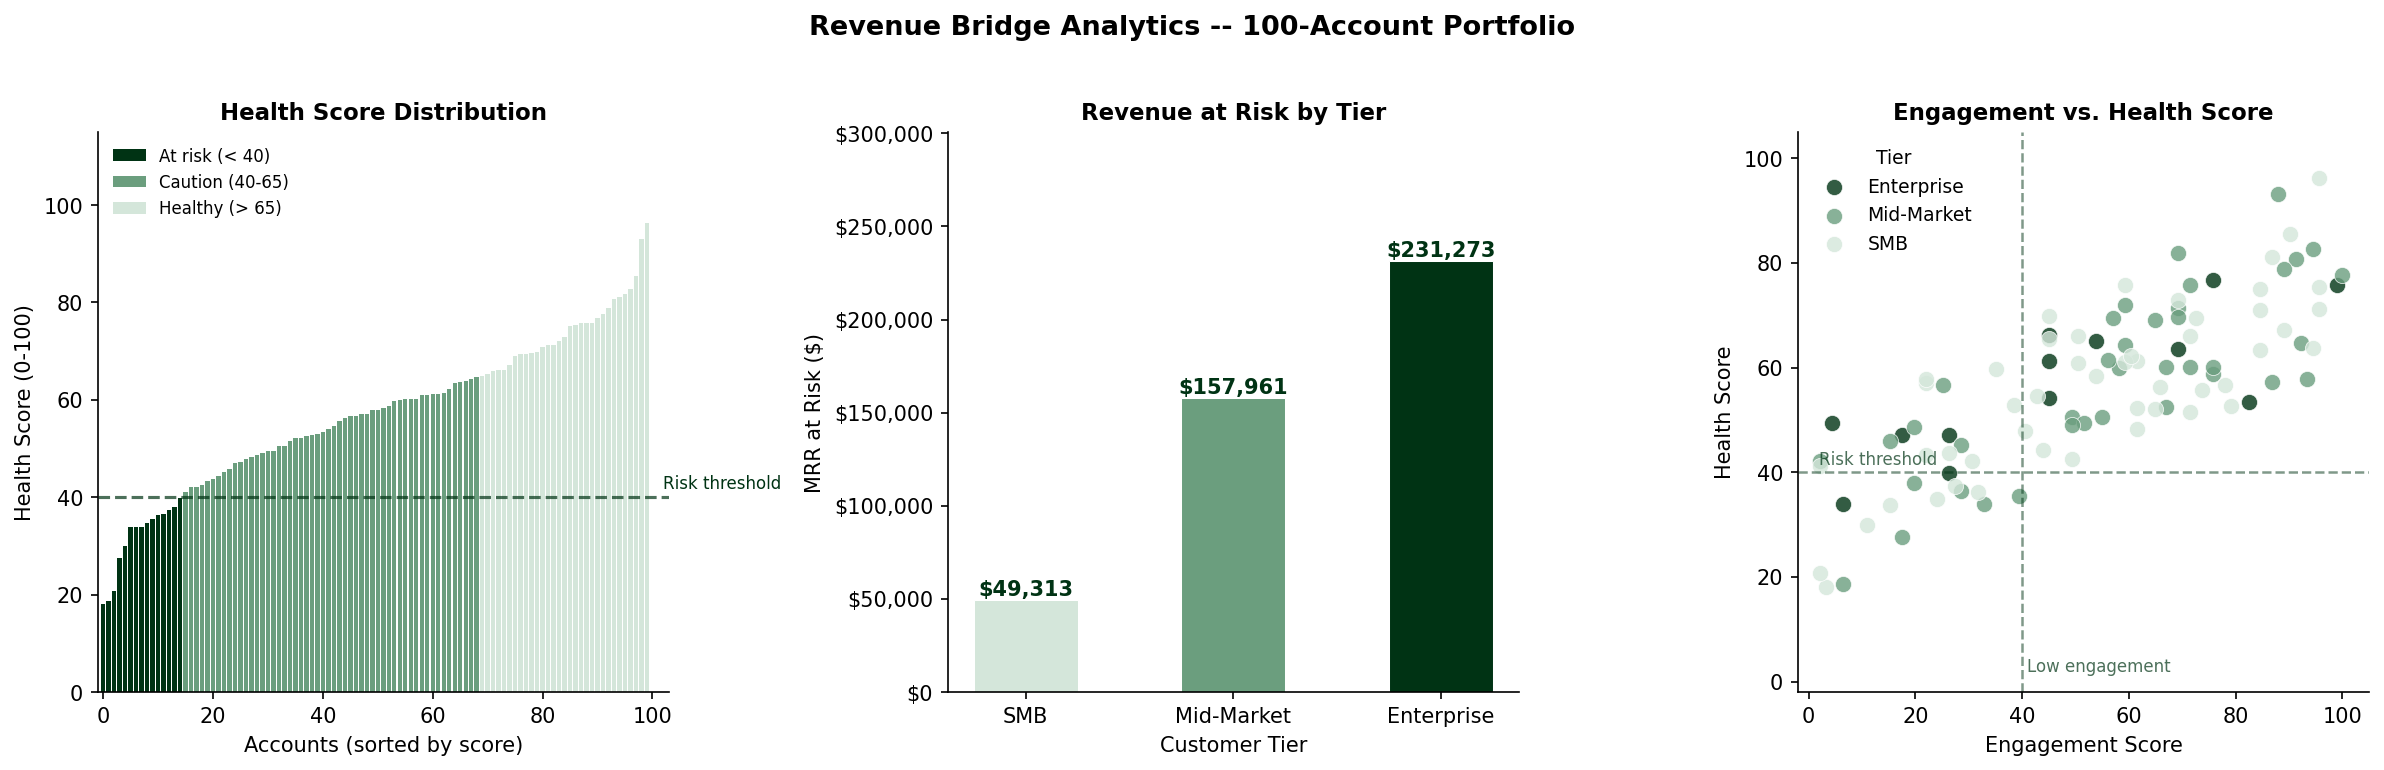

In [4]:
from IPython.display import Image
Image("outputs/health_score_distribution.png")